<a href="https://colab.research.google.com/github/ver1812/Capstone_Project/blob/main/models/ModernBERT_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transfer Learning: ModernBERT-base

**Final model in the Transfer Learning**

In [1]:
import os
import json
import time
import random

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

try:
    import transformers
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "transformers"], check=True)
    import transformers

# ModernBERT support requires transformers >= 4.48.0
from packaging import version
if version.parse(transformers.__version__) < version.parse("4.48.0"):
    print(f"WARNING: transformers=={transformers.__version__} - ModernBERT needs >=4.48.0.")
    import subprocess
    subprocess.run(["pip", "install", "-q", "-U", "transformers"], check=True)
    import importlib
    importlib.reload(transformers)
    print(f"Upgraded to transformers=={transformers.__version__}")

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
)

print(f"transformers version: {transformers.__version__}")
print(f"torch version: {torch.__version__}")


transformers version: 5.13.1
torch version: 2.11.0+cu128


### Environment setup (Colab)

In [2]:
import platform

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("=== ENVIRONMENT CHECK ===")
print(f"Platform:       {platform.system()} {platform.machine()}")
print(f"IN_COLAB:       {IN_COLAB}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:            {torch.cuda.get_device_name(0)}")
    print(f"GPU memory:     {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: no GPU detected — check Runtime > Change runtime type > GPU.")

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

BASE_DIR = "/content/drive/MyDrive/Capstone" if IN_COLAB else ".."
DATA_DIR = f"{BASE_DIR}/data_v2"
print(f"BASE_DIR: {BASE_DIR}")
print(f"DATA_DIR: {DATA_DIR}")


=== ENVIRONMENT CHECK ===
Platform:       Linux x86_64
IN_COLAB:       True
CUDA available: True
GPU:            NVIDIA A100-SXM4-80GB
GPU memory:     85.1 GB
Mounted at /content/drive
BASE_DIR: /content/drive/MyDrive/Capstone
DATA_DIR: /content/drive/MyDrive/Capstone/data_v2


### Config

In [3]:
SEED = 42

MODEL_NAME = "answerdotai/ModernBERT-base"
MODEL_SLUG = "modernbert"

# Data
TEXT_COL = "text"
LABEL_COL = "label"

MAX_LEN = None


BATCH_SIZE = 16
LEARNING_RATE = 2e-5
WARMUP_RATIO = 0.1
MAX_EPOCHS = 8
PATIENCE = 3
GRAD_CLIP = 1.0
USE_AMP = True

# Artifacts -- Capstone/saved/{MODEL_SLUG} on Drive
SAVE_DIR = f"{BASE_DIR}/saved/{MODEL_SLUG}"
os.makedirs(SAVE_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = USE_AMP and DEVICE.type == "cuda"
# ------------------------------------------------------------------


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Model: {MODEL_NAME}")
print(f"AMP enabled: {AMP_ENABLED}")
print(f"Save dir: {SAVE_DIR}")


Device: cuda
GPU: NVIDIA A100-SXM4-80GB
Model: answerdotai/ModernBERT-base
AMP enabled: True
Save dir: /content/drive/MyDrive/Capstone/saved/modernbert


In [4]:
TRAIN_PATH = f"{DATA_DIR}/train_v2.csv"
VAL_PATH   = f"{DATA_DIR}/val_v2.csv"
TEST_PATH  = f"{DATA_DIR}/test_v2.csv"

for _name, _path in [("train_v2.csv", TRAIN_PATH), ("val_v2.csv", VAL_PATH), ("test_v2.csv", TEST_PATH)]:
    if not os.path.exists(_path):
        raise FileNotFoundError(
            f"{_name} not found at {_path} — check DATA_DIR is correct and the "
            "files actually live in that Drive folder."
        )


def load_split(path, text_col, label_col):
    frame = pd.read_csv(path)
    frame[text_col] = frame[text_col].fillna("").astype(str)
    frame[label_col] = frame[label_col].astype(int)
    return frame


train_df = load_split(TRAIN_PATH, TEXT_COL, LABEL_COL)
val_df   = load_split(VAL_PATH,   TEXT_COL, LABEL_COL)
test_df  = load_split(TEST_PATH,  TEXT_COL, LABEL_COL)

for name, frame in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"{name:<6} {len(frame):>7,} rows | {frame[LABEL_COL].mean():.4f} positive")


Train   14,429 rows | 0.4784 positive
Val      3,092 rows | 0.4783 positive
Test     3,093 rows | 0.4785 positive


### Tokenizer & sequence length


In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Real token counts with NO truncation, to see the true distribution
train_encodings_full = tokenizer(list(train_df[TEXT_COL]), truncation=False)
train_lengths = np.array([len(ids) for ids in train_encodings_full["input_ids"]])

percentiles = [50, 75, 90, 95, 97, 99]
print(f"Token-length percentiles (train set, {MODEL_NAME} tokenizer):")
for p in percentiles:
    print(f"  p{p:>2}: {int(np.percentile(train_lengths, p)):>6,}")
print(f"  max: {train_lengths.max():>6,}")
print(f" mean: {train_lengths.mean():>6.1f}")

del train_encodings_full  # free memory — only needed the lengths


config.json:   0%|          | 0.00/1.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/20.8k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.13M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (9912 > 8192). Running this sequence through the model will result in indexing errors


Token-length percentiles (train set, answerdotai/ModernBERT-base tokenizer):
  p50:    123
  p75:    199
  p90:    362
  p95:    714
  p97:  1,155
  p99:  3,832
  max: 10,144
 mean:  256.6


In [7]:
candidate_lengths = [128, 256, 512, 1024, 2048, 4096, 8192]

print("Coverage sweep (train set, ModernBERT tokenizer):")
for candidate in candidate_lengths:
    cov_overall = (train_lengths <= candidate).mean()
    cov_benign = (train_lengths[train_df[LABEL_COL].values == 0] <= candidate).mean()
    cov_malicious = (train_lengths[train_df[LABEL_COL].values == 1] <= candidate).mean()
    print(f"  MAX_LEN = {candidate:>5}: overall {cov_overall:.2%} | benign {cov_benign:.2%} | malicious {cov_malicious:.2%}")


MAX_LEN = 4096

coverage_overall = (train_lengths <= MAX_LEN).mean()
coverage_benign = (train_lengths[train_df[LABEL_COL].values == 0] <= MAX_LEN).mean()
coverage_malicious = (train_lengths[train_df[LABEL_COL].values == 1] <= MAX_LEN).mean()

print(f"\nLOCKED: MAX_LEN = {MAX_LEN}")
print(f"Overall coverage:   {coverage_overall:.2%}")
print(f"Benign coverage:    {coverage_benign:.2%}")
print(f"Malicious coverage: {coverage_malicious:.2%}")


Coverage sweep (train set, ModernBERT tokenizer):
  MAX_LEN =   128: overall 52.59% | benign 59.01% | malicious 45.59%
  MAX_LEN =   256: overall 81.65% | benign 84.32% | malicious 78.73%
  MAX_LEN =   512: overall 92.53% | benign 92.11% | malicious 92.99%
  MAX_LEN =  1024: overall 96.78% | benign 94.46% | malicious 99.30%
  MAX_LEN =  2048: overall 97.60% | benign 95.77% | malicious 99.59%
  MAX_LEN =  4096: overall 99.09% | benign 98.29% | malicious 99.96%
  MAX_LEN =  8192: overall 99.95% | benign 99.91% | malicious 100.00%

LOCKED: MAX_LEN = 4096
Overall coverage:   99.09%
Benign coverage:    98.29%
Malicious coverage: 99.96%


### Dataset & DataLoader (dynamic padding)
Sequences are tokenized to variable length (no fixed padding here) and padded per-batch by `DataCollatorWithPadding`

In [8]:
class TransformerPromptDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(list(texts), truncation=True, max_length=max_len, padding=False)
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item


data_collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")

train_ds = TransformerPromptDataset(train_df[TEXT_COL], train_df[LABEL_COL], tokenizer, MAX_LEN)
val_ds   = TransformerPromptDataset(val_df[TEXT_COL],   val_df[LABEL_COL],   tokenizer, MAX_LEN)
test_ds  = TransformerPromptDataset(test_df[TEXT_COL],  test_df[LABEL_COL],  tokenizer, MAX_LEN)

generator = torch.Generator()
generator.manual_seed(SEED)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=generator, collate_fn=data_collator)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=data_collator)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=data_collator)

print(f"Batches — train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}")


Batches — train: 902, val: 194, test: 194


### Model

In [9]:

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=1, torch_dtype=torch.float32
).to(DEVICE)

print(f"Attention implementation in use: {model.config._attn_implementation}")

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model on device: {next(model.parameters()).device}")
print(f"Model dtype: {next(model.parameters()).dtype}")


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B /  599MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Attention implementation in use: sdpa
Total parameters:     149,605,633
Trainable parameters: 149,605,633
Model on device: cuda:0
Model dtype: torch.float32


### Loss, optimizer, scheduler

In [10]:
num_neg = int((train_df[LABEL_COL] == 0).sum())
num_pos = int((train_df[LABEL_COL] == 1).sum())
pos_weight_value = num_neg / num_pos

print(f"Negatives: {num_neg:,} | Positives: {num_pos:,}")
print(f"pos_weight = {pos_weight_value:.4f}")

pos_weight = torch.tensor([pos_weight_value], dtype=torch.float, device=DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

total_steps = len(train_loader) * MAX_EPOCHS
warmup_steps = int(WARMUP_RATIO * total_steps)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

print(f"Total optimizer steps: {total_steps:,} (warmup: {warmup_steps:,})")


Negatives: 7,526 | Positives: 6,903
pos_weight = 1.0903
Total optimizer steps: 7,216 (warmup: 721)


/tmp/ipykernel_1039/3435023473.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)


### Train and evaluate functions

In [11]:
def train_one_epoch(model, loader, criterion, optimizer, scheduler, scaler, device, grad_clip, epoch_num, total_epochs, print_every=40):
    model.train()
    running_loss = 0.0
    n_batches = len(loader)
    batch_start = time.time()
    skipped_batches = 0

    for batch_idx, batch in enumerate(loader, start=1):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=AMP_ENABLED):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits.squeeze(-1)
            loss = criterion(logits, labels)

        if torch.isnan(loss) or torch.isinf(loss):
            print(f"  [Epoch {epoch_num}] batch {batch_idx}: NaN/Inf loss detected — skipping batch (no backward call)")
            skipped_batches += 1
            continue

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        grad_norm = nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        if torch.isnan(grad_norm) or torch.isinf(grad_norm):
            print(f"  [Epoch {epoch_num}] batch {batch_idx}: NaN/Inf gradient — GradScaler will skip this optimizer step")
            skipped_batches += 1

        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        running_loss += loss.item() * input_ids.size(0)

        if batch_idx == 1 or batch_idx % print_every == 0 or batch_idx == n_batches:
            elapsed = time.time() - batch_start
            avg_batch_time = elapsed / batch_idx
            eta_sec = avg_batch_time * (n_batches - batch_idx)
            print(
                f"  [Epoch {epoch_num}/{total_epochs}] batch {batch_idx}/{n_batches} "
                f"| loss {loss.item():.4f} | {avg_batch_time:.2f}s/batch | ETA {eta_sec:.0f}s",
                flush=True,
            )

    if skipped_batches > 0:
        print(f"  Epoch {epoch_num}: {skipped_batches} batch(es) skipped due to numerical instability")

    return running_loss / len(loader.dataset)


def predict(model, loader, criterion, device, desc="eval"):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            with torch.cuda.amp.autocast(enabled=AMP_ENABLED):
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                logits = outputs.logits.squeeze(-1)
                loss = criterion(logits, labels)

            running_loss += loss.item() * input_ids.size(0)

            probs = torch.sigmoid(logits.float())
            all_labels.append(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)
    return avg_loss, np.concatenate(all_labels), np.concatenate(all_probs)


### Helper functions

In [12]:
def evaluate_predictions(y_true, y_prob, threshold=0.5, split_name=""):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "split": split_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
    }


def print_metrics(metrics):
    print(f"--- {metrics['split']} (threshold={metrics['threshold']:.2f}) ---")
    for key in ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]:
        print(f"  {key:<10}: {metrics[key]:.4f}")


Quick timing check before committing to the full run — same pattern used throughout this project. Given the uncertainty flagged earlier about per-model training cost, don't skip this one.

In [13]:
model.train()
single_batch = next(iter(train_loader))
input_ids = single_batch["input_ids"].to(DEVICE)
attention_mask = single_batch["attention_mask"].to(DEVICE)
labels = single_batch["labels"].to(DEVICE)

start = time.time()
optimizer.zero_grad()
with torch.cuda.amp.autocast(enabled=AMP_ENABLED):
    outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    logits = outputs.logits.squeeze(-1)
    loss = criterion(logits, labels)
scaler.scale(loss).backward()
scaler.unscale_(optimizer)
nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
scaler.step(optimizer)
scaler.update()
scheduler.step()
if DEVICE.type == "cuda":
    torch.cuda.synchronize()
batch_time = time.time() - start

print(f"Single batch time ({DEVICE}, AMP={AMP_ENABLED}, MAX_LEN={MAX_LEN}, batch={BATCH_SIZE}): {batch_time:.3f}s")
print(f"Batches per epoch: {len(train_loader)}")
print(f"Rough epoch estimate: {batch_time * len(train_loader) / 60:.1f} min")
print(f"Rough {MAX_EPOCHS}-epoch estimate: {batch_time * len(train_loader) * MAX_EPOCHS / 60:.1f} min")



/tmp/ipykernel_1039/1489721777.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP_ENABLED):


Single batch time (cuda, AMP=True, MAX_LEN=4096, batch=16): 1.507s
Batches per epoch: 902
Rough epoch estimate: 22.7 min
Rough 8-epoch estimate: 181.2 min


### Training loop

In [14]:
best_val_f1 = -1.0
best_epoch = -1
epochs_without_improvement = 0
history = []

checkpoint_dir = os.path.join(SAVE_DIR, f"{MODEL_SLUG}_best")

print(f"Starting training — up to {MAX_EPOCHS} epochs, early stopping patience={PATIENCE}\n")

for epoch in range(1, MAX_EPOCHS + 1):
    start = time.time()

    train_loss = train_one_epoch(
        model, train_loader, criterion, optimizer, scheduler, scaler,
        DEVICE, GRAD_CLIP, epoch, MAX_EPOCHS
    )
    val_loss, val_true, val_prob = predict(model, val_loader, criterion, DEVICE, desc=f"Epoch {epoch}/{MAX_EPOCHS} [val]")
    val_metrics = evaluate_predictions(val_true, val_prob, 0.5, "val")

    elapsed = time.time() - start

    history.append({
        "epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
        "val_f1": val_metrics["f1"], "val_recall": val_metrics["recall"],
        "val_precision": val_metrics["precision"], "seconds": elapsed,
    })

    print(
        f"Epoch {epoch:>2}/{MAX_EPOCHS} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f} "
        f"| val_F1 {val_metrics['f1']:.4f} | val_recall {val_metrics['recall']:.4f} | {elapsed:.1f}s"
    )

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        best_epoch = epoch
        epochs_without_improvement = 0
        model.save_pretrained(checkpoint_dir)
        tokenizer.save_pretrained(checkpoint_dir)
        print("         -> new best val F1, checkpoint saved")
    else:
        epochs_without_improvement += 1
        print(f"         -> no improvement ({epochs_without_improvement}/{PATIENCE})")
        if epochs_without_improvement >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}. Best epoch: {best_epoch}, best val F1: {best_val_f1:.4f}.")
            break

history_df = pd.DataFrame(history)
print(f"\nTraining complete. Best val F1 = {best_val_f1:.4f} at epoch {best_epoch}")


Starting training — up to 8 epochs, early stopping patience=3



/tmp/ipykernel_1039/433618047.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP_ENABLED):


  [Epoch 1] batch 1: NaN/Inf gradient — GradScaler will skip this optimizer step
  [Epoch 1/8] batch 1/902 | loss 0.9541 | 1.76s/batch | ETA 1589s
  [Epoch 1] batch 21: NaN/Inf gradient — GradScaler will skip this optimizer step
  [Epoch 1/8] batch 40/902 | loss 0.6402 | 0.48s/batch | ETA 417s
  [Epoch 1/8] batch 80/902 | loss 0.6534 | 0.53s/batch | ETA 434s
  [Epoch 1/8] batch 120/902 | loss 0.4093 | 0.56s/batch | ETA 434s
  [Epoch 1/8] batch 160/902 | loss 0.3917 | 0.55s/batch | ETA 411s
  [Epoch 1] batch 166: NaN/Inf gradient — GradScaler will skip this optimizer step
  [Epoch 1/8] batch 200/902 | loss 0.5659 | 0.57s/batch | ETA 401s
  [Epoch 1/8] batch 240/902 | loss 0.4219 | 0.57s/batch | ETA 374s
  [Epoch 1/8] batch 280/902 | loss 0.3588 | 0.56s/batch | ETA 350s
  [Epoch 1] batch 306: NaN/Inf gradient — GradScaler will skip this optimizer step
  [Epoch 1/8] batch 320/902 | loss 0.3253 | 0.59s/batch | ETA 344s
  [Epoch 1/8] batch 360/902 | loss 0.0846 | 0.57s/batch | ETA 309s
  [E

/tmp/ipykernel_1039/433618047.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP_ENABLED):


Epoch  1/8 | train_loss 0.3668 | val_loss 0.2150 | val_F1 0.9146 | val_recall 0.8729 | 519.2s


...

Epoch  6/8 | train_loss 0.0302 | val_loss 0.3576 | val_F1 0.9393 | val_recall 0.9209 | 537.7s
         -> no improvement (2/3)
  [Epoch 7/8] batch 1/902 | loss 0.0036 | 0.18s/batch | ETA 158s


/tmp/ipykernel_1039/433618047.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP_ENABLED):


  [Epoch 7/8] batch 40/902 | loss 0.0000 | 0.35s/batch | ETA 300s
  [Epoch 7/8] batch 80/902 | loss 0.0042 | 0.38s/batch | ETA 312s
  [Epoch 7/8] batch 120/902 | loss 0.0000 | 0.46s/batch | ETA 360s
  [Epoch 7/8] batch 160/902 | loss 0.0000 | 0.48s/batch | ETA 354s
  [Epoch 7/8] batch 200/902 | loss 0.0045 | 0.52s/batch | ETA 368s
  [Epoch 7/8] batch 240/902 | loss 0.0033 | 0.55s/batch | ETA 363s
  [Epoch 7/8] batch 280/902 | loss 0.0743 | 0.55s/batch | ETA 344s
  [Epoch 7/8] batch 320/902 | loss 0.0018 | 0.55s/batch | ETA 323s
  [Epoch 7/8] batch 360/902 | loss 0.0000 | 0.55s/batch | ETA 298s
  [Epoch 7/8] batch 400/902 | loss 0.0000 | 0.54s/batch | ETA 274s
  [Epoch 7/8] batch 440/902 | loss 0.0000 | 0.54s/batch | ETA 248s
  [Epoch 7/8] batch 480/902 | loss 0.0001 | 0.53s/batch | ETA 223s
  [Epoch 7/8] batch 520/902 | loss 0.0044 | 0.53s/batch | ETA 203s
  [Epoch 7/8] batch 560/902 | loss 0.0062 | 0.54s/batch | ETA 186s
  [Epoch 7/8] batch 600/902 | loss 0.0024 | 0.54s/batch | ETA 16

/tmp/ipykernel_1039/433618047.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP_ENABLED):


Epoch  7/8 | train_loss 0.0233 | val_loss 0.3774 | val_F1 0.9423 | val_recall 0.9337 | 524.9s
         -> no improvement (3/3)

Early stopping at epoch 7. Best epoch: 4, best val F1: 0.9478.

Training complete. Best val F1 = 0.9478 at epoch 4


Training curves

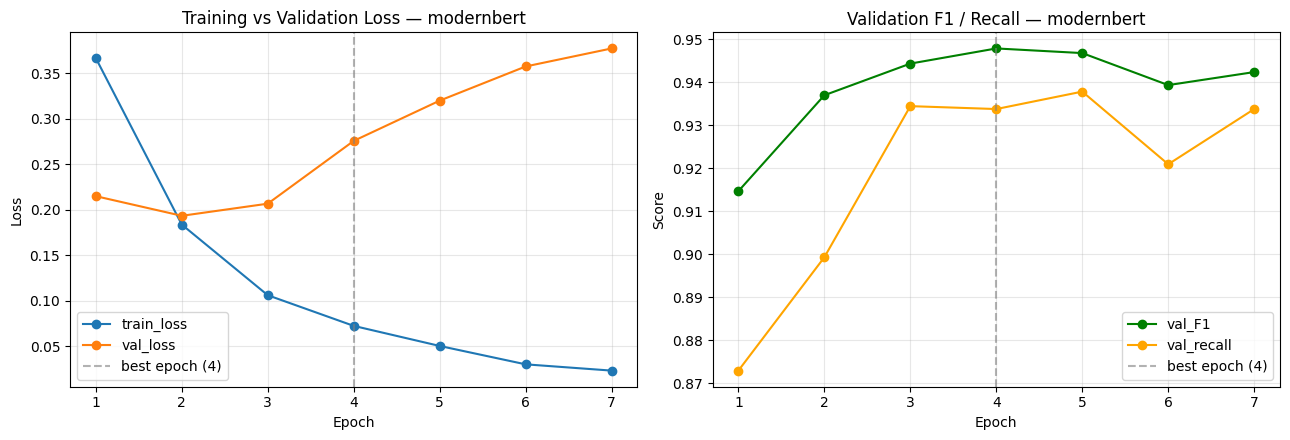

Saved: /content/drive/MyDrive/Capstone/saved/modernbert/loss_curve_modernbert.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train_loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val_loss")
axes[0].axvline(best_epoch, color="gray", linestyle="--", alpha=0.6, label=f"best epoch ({best_epoch})")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title(f"Training vs Validation Loss — {MODEL_SLUG}")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_df["epoch"], history_df["val_f1"], marker="o", color="green", label="val_F1")
axes[1].plot(history_df["epoch"], history_df["val_recall"], marker="o", color="orange", label="val_recall")
axes[1].axvline(best_epoch, color="gray", linestyle="--", alpha=0.6, label=f"best epoch ({best_epoch})")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_title(f"Validation F1 / Recall — {MODEL_SLUG}")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
loss_curve_path = os.path.join(SAVE_DIR, f"loss_curve_{MODEL_SLUG}.png")
plt.savefig(loss_curve_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {loss_curve_path}")


### Load checkpoint and evaluate

In [16]:
model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint_dir, torch_dtype=torch.float32
).to(DEVICE)

_, val_true, val_prob = predict(model, val_loader, criterion, DEVICE, desc="final val")
val_metrics = evaluate_predictions(val_true, val_prob, 0.5, "val")
print_metrics(val_metrics)

_, test_true, test_prob = predict(model, test_loader, criterion, DEVICE, desc="final test")
test_metrics = evaluate_predictions(test_true, test_prob, 0.5, "test")
print_metrics(test_metrics)

print("\nConfusion matrix (test, threshold=0.5):")
test_pred = (test_prob >= 0.5).astype(int)
cm = confusion_matrix(test_true, test_pred)
print(pd.DataFrame(cm, index=["actual_benign", "actual_malicious"], columns=["pred_benign", "pred_malicious"]))

print("\n" + classification_report(test_true, test_pred, digits=4))


Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

/tmp/ipykernel_1039/433618047.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP_ENABLED):


--- val (threshold=0.50) ---
  accuracy  : 0.9508
  precision : 0.9624
  recall    : 0.9337
  f1        : 0.9478
  roc_auc   : 0.9861
  pr_auc    : 0.9866


/tmp/ipykernel_1039/433618047.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP_ENABLED):


--- test (threshold=0.50) ---
  accuracy  : 0.9512
  precision : 0.9723
  recall    : 0.9243
  f1        : 0.9477
  roc_auc   : 0.9854
  pr_auc    : 0.9872

Confusion matrix (test, threshold=0.5):
                  pred_benign  pred_malicious
actual_benign            1574              39
actual_malicious          112            1368

              precision    recall  f1-score   support

         0.0     0.9336    0.9758    0.9542      1613
         1.0     0.9723    0.9243    0.9477      1480

    accuracy                         0.9512      3093
   macro avg     0.9529    0.9501    0.9510      3093
weighted avg     0.9521    0.9512    0.9511      3093



ROC curve

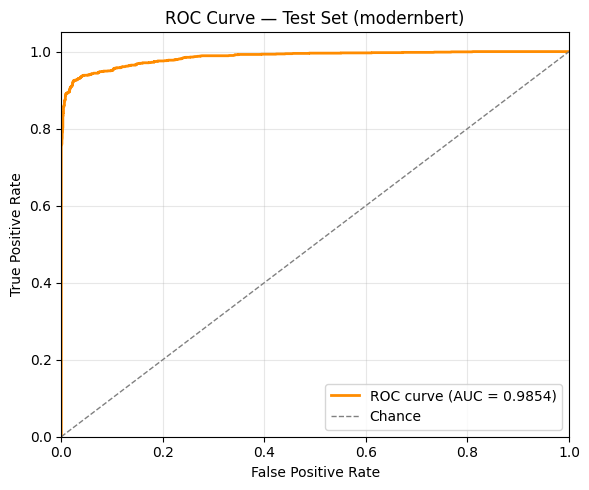

Saved: /content/drive/MyDrive/Capstone/saved/modernbert/roc_curve_modernbert.png


In [17]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(test_true, test_prob)
roc_auc_value = test_metrics["roc_auc"]

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc_value:.4f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Chance")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve — Test Set ({MODEL_SLUG})")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()

roc_path = os.path.join(SAVE_DIR, f"roc_curve_{MODEL_SLUG}.png")
plt.savefig(roc_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {roc_path}")


Confusion matrix (visual)

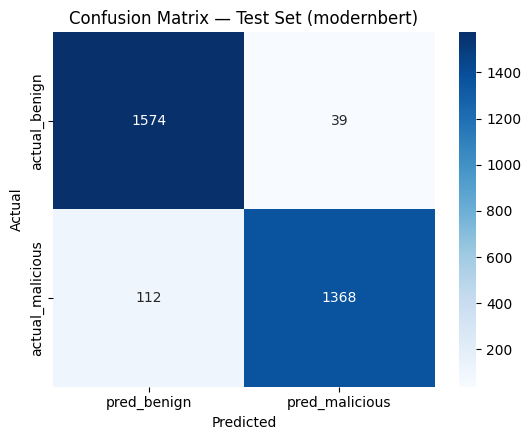

Saved: /content/drive/MyDrive/Capstone/saved/modernbert/confusion_matrix_modernbert.png


In [18]:
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["pred_benign", "pred_malicious"],
    yticklabels=["actual_benign", "actual_malicious"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — Test Set ({MODEL_SLUG})")
plt.tight_layout()

cm_path = os.path.join(SAVE_DIR, f"confusion_matrix_{MODEL_SLUG}.png")
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {cm_path}")


Confusion matrix (visual) — validation set

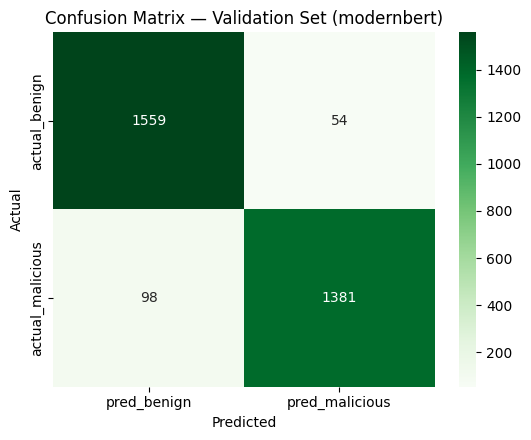

Saved: /content/drive/MyDrive/Capstone/saved/modernbert/confusion_matrix_val_modernbert.png


In [19]:
val_pred = (val_prob >= 0.5).astype(int)
val_cm = confusion_matrix(val_true, val_pred)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(
    val_cm, annot=True, fmt="d", cmap="Greens",
    xticklabels=["pred_benign", "pred_malicious"],
    yticklabels=["actual_benign", "actual_malicious"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — Validation Set ({MODEL_SLUG})")
plt.tight_layout()

val_cm_path = os.path.join(SAVE_DIR, f"confusion_matrix_val_{MODEL_SLUG}.png")
plt.savefig(val_cm_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {val_cm_path}")


### Save metrics/history

In [20]:
config = {
    "seed": SEED,
    "model_name": MODEL_NAME,
    "model_slug": MODEL_SLUG,
    "max_len": MAX_LEN,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "warmup_ratio": WARMUP_RATIO,
    "max_epochs": MAX_EPOCHS,
    "patience": PATIENCE,
    "grad_clip": GRAD_CLIP,
    "amp_enabled": AMP_ENABLED,
    "pos_weight": pos_weight_value,
    "best_epoch": best_epoch,
    "best_val_f1": best_val_f1,
    "total_params": total_params,
    "trainable_params": trainable_params,
    "device": str(DEVICE),
}
with open(os.path.join(SAVE_DIR, f"config_{MODEL_SLUG}.json"), "w") as f:
    json.dump(config, f, indent=2)

results = pd.DataFrame([val_metrics, test_metrics])
results.to_csv(os.path.join(SAVE_DIR, f"metrics_{MODEL_SLUG}.csv"), index=False)
history_df.to_csv(os.path.join(SAVE_DIR, f"history_{MODEL_SLUG}.csv"), index=False)

print("Saved:")
for root, dirs, files in os.walk(SAVE_DIR):
    for f in files:
        print(f"  {os.path.join(root, f)}")

results


Saved:
  /content/drive/MyDrive/Capstone/saved/modernbert/loss_curve_modernbert.png
  /content/drive/MyDrive/Capstone/saved/modernbert/roc_curve_modernbert.png
  /content/drive/MyDrive/Capstone/saved/modernbert/confusion_matrix_modernbert.png
  /content/drive/MyDrive/Capstone/saved/modernbert/confusion_matrix_val_modernbert.png
  /content/drive/MyDrive/Capstone/saved/modernbert/config_modernbert.json
  /content/drive/MyDrive/Capstone/saved/modernbert/metrics_modernbert.csv
  /content/drive/MyDrive/Capstone/saved/modernbert/history_modernbert.csv
  /content/drive/MyDrive/Capstone/saved/modernbert/modernbert_best/config.json
  /content/drive/MyDrive/Capstone/saved/modernbert/modernbert_best/model.safetensors
  /content/drive/MyDrive/Capstone/saved/modernbert/modernbert_best/tokenizer_config.json
  /content/drive/MyDrive/Capstone/saved/modernbert/modernbert_best/tokenizer.json


,split,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,val,0.5,0.950841,0.962369,0.933739,0.947838,0.986054,0.986565
1,test,0.5,0.951180,0.972281,0.924324,0.947697,0.985409,0.987198


Results summary (JSON, matches the traditional ML / BiLSTM v2 format — includes raw confusion-matrix counts)

In [21]:
tn, fp, fn, tp = cm.ravel()
val_tn, val_fp, val_fn, val_tp = val_cm.ravel()

results_summary = {
    MODEL_SLUG: {
        "config": MODEL_SLUG,
        "validation": val_metrics,
        "test": test_metrics,
        "validation_confusion_matrix": {
            "tn": int(val_tn), "fp": int(val_fp), "fn": int(val_fn), "tp": int(val_tp),
        },
        "test_confusion_matrix": {
            "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        },
    }
}

results_json_path = os.path.join(SAVE_DIR, f"{MODEL_SLUG}_results.json")
with open(results_json_path, "w") as f:
    json.dump(results_summary, f, indent=2)

print(f"Saved results summary to {results_json_path}")
print(f"Test:       TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Validation: TN={val_tn}, FP={val_fp}, FN={val_fn}, TP={val_tp}")


Saved results summary to /content/drive/MyDrive/Capstone/saved/modernbert/modernbert_results.json
Test:       TN=1574, FP=39, FN=112, TP=1368
Validation: TN=1559, FP=54, FN=98, TP=1381


Zip artifacts for download

 threshold  accuracy  precision  recall     f1  FN  FP
      0.05    0.9282     0.8996  0.9567 0.9273  64 158
      0.10    0.9450     0.9401  0.9452 0.9427  81  89
      0.15    0.9473     0.9488  0.9405 0.9447  88  75
      0.20    0.9479     0.9514  0.9391 0.9452  90  71
      0.25    0.9483     0.9551  0.9358 0.9454  95  65
      0.30    0.9495     0.9584  0.9351 0.9466  96  60
      0.35    0.9502     0.9604  0.9344 0.9472  97  57
      0.40    0.9502     0.9610  0.9337 0.9472  98  56
      0.45    0.9508     0.9624  0.9337 0.9478  98  54
      0.50    0.9508     0.9624  0.9337 0.9478  98  54
      0.55    0.9505     0.9623  0.9331 0.9475  99  54
      0.60    0.9505     0.9623  0.9331 0.9475  99  54
      0.65    0.9502     0.9623  0.9324 0.9471 100  54
      0.70    0.9502     0.9636  0.9310 0.9470 102  52
      0.75    0.9521     0.9677  0.9310 0.9490 102  46
      0.80    0.9521     0.9683  0.9304 0.9490 103  45
      0.85    0.9508     0.9689  0.9270 0.9475 108  44
      0.90

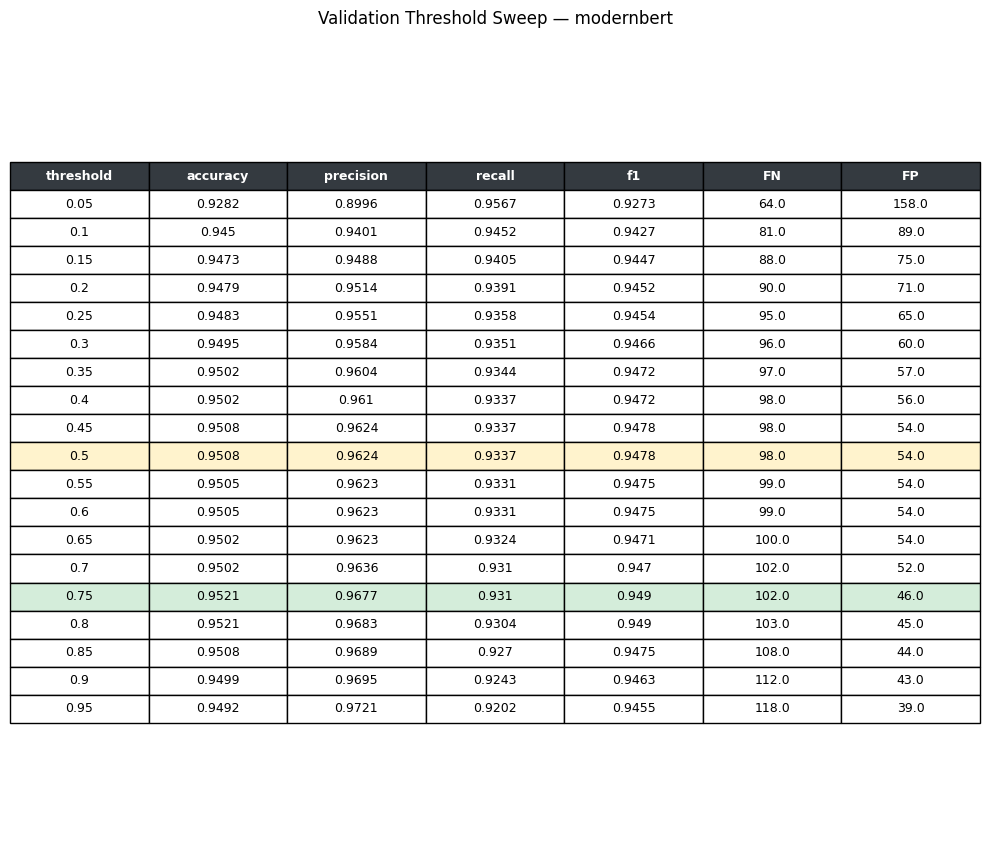

Saved: /content/drive/MyDrive/Capstone/saved/modernbert/threshold_sweep_table_modernbert.png


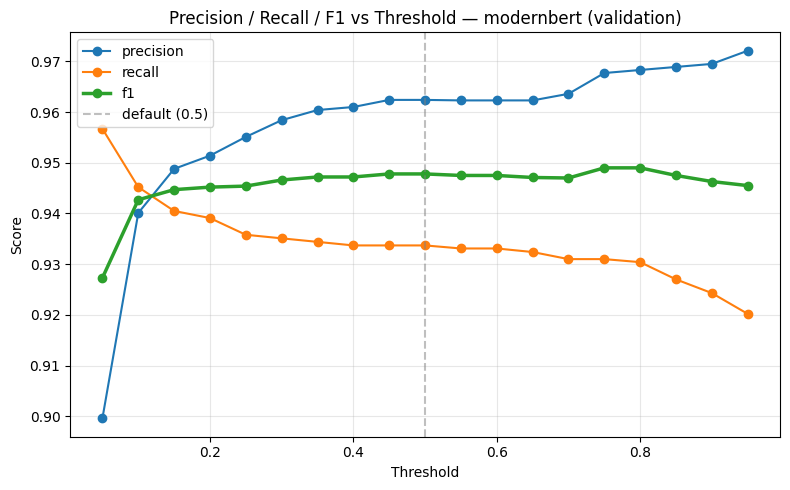

Saved: /content/drive/MyDrive/Capstone/saved/modernbert/threshold_tradeoff_modernbert.png


In [22]:
thresholds_to_check = np.arange(0.05, 0.96, 0.05)

sweep_rows = []
for t in thresholds_to_check:
    m = evaluate_predictions(val_true, val_prob, threshold=t, split_name="val")
    pred = (val_prob >= t).astype(int)
    fn = int(((val_true == 1) & (pred == 0)).sum())
    fp = int(((val_true == 0) & (pred == 1)).sum())
    sweep_rows.append({
        "threshold": round(float(t), 2),
        "accuracy": round(m["accuracy"], 4),
        "precision": round(m["precision"], 4),
        "recall": round(m["recall"], 4),
        "f1": round(m["f1"], 4),
        "FN": fn,
        "FP": fp,
    })

sweep_df = pd.DataFrame(sweep_rows)
print(sweep_df.to_string(index=False))

# --- Graphic table ---
fig, ax = plt.subplots(figsize=(10, 0.4 * len(sweep_df) + 1))
ax.axis("off")

table = ax.table(
    cellText=sweep_df.values,
    colLabels=sweep_df.columns,
    cellLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.4)

default_idx = sweep_df.index[sweep_df["threshold"] == 0.50].tolist()
if default_idx:
    for col in range(len(sweep_df.columns)):
        table[(default_idx[0] + 1, col)].set_facecolor("#FFF3CD")

best_f1_idx = int(sweep_df["f1"].idxmax())
for col in range(len(sweep_df.columns)):
    table[(best_f1_idx + 1, col)].set_facecolor("#D4EDDA")

for col in range(len(sweep_df.columns)):
    table[(0, col)].set_facecolor("#343A40")
    table[(0, col)].set_text_props(color="white", weight="bold")

plt.title(f"Validation Threshold Sweep — {MODEL_SLUG}", fontsize=12, pad=15)
plt.tight_layout()

sweep_table_path = os.path.join(SAVE_DIR, f"threshold_sweep_table_{MODEL_SLUG}.png")
plt.savefig(sweep_table_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {sweep_table_path}")

# --- Tradeoff curve ---
plt.figure(figsize=(8, 5))
plt.plot(sweep_df["threshold"], sweep_df["precision"], marker="o", label="precision")
plt.plot(sweep_df["threshold"], sweep_df["recall"], marker="o", label="recall")
plt.plot(sweep_df["threshold"], sweep_df["f1"], marker="o", label="f1", linewidth=2.5)
plt.axvline(0.5, color="gray", linestyle="--", alpha=0.5, label="default (0.5)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title(f"Precision / Recall / F1 vs Threshold — {MODEL_SLUG} (validation)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

tradeoff_path = os.path.join(SAVE_DIR, f"threshold_tradeoff_{MODEL_SLUG}.png")
plt.savefig(tradeoff_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {tradeoff_path}")

In [23]:
import shutil

zip_path = shutil.make_archive(
    base_name=f"{BASE_DIR}/{MODEL_SLUG}_artifacts",
    format="zip",
    root_dir=SAVE_DIR,
)
print(f"Zipped to: {zip_path}")
print(f"Size: {os.path.getsize(zip_path) / 1e6:.2f} MB")


Zipped to: /content/drive/MyDrive/Capstone/modernbert_artifacts.zip
Size: 556.94 MB
